<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Análisis Multivariado</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2025/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [15]:
# Solicitar datos al estudiante
nombre = input("Ingresa tu nombre completo: ")
correo = input("Ingresa tu correo electrónico: ")

# Mostrar los datos ingresados
print("\nResumen de datos ingresados:")
print(f"Nombre: {nombre}")
print(f"Correo electrónico: {correo}")


Resumen de datos ingresados:
Nombre: Thomas GIRAULT
Correo electrónico: thoma19girault@gmail.com


## <span style="color:black;"><strong>Parte 3: Análisis Multivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio1: Análisis de componentes principales</strong></span>

A partir de un conjunto de datos real sobre pingüinos antárticos, realiza un análisis multivariado utilizando PCA para reducir la dimensionalidad y visualizar agrupamientos por especie.

1. Carga el conjunto de datos penguins desde la librería seaborn `load_dataset("penguins")`.
2. Selecciona las siguientes variables morfológicas para el análisis:
   - 'bill_length_mm'
   - 'bill_depth_mm'
   - 'flipper_length_mm'
   - 'body_mass_g'
3. Estandariza las variables seleccionadas usando StandardScaler.
4. Aplica PCA()
5. Imprime las ecuaciones que obtuviste para el número de componentes que utilizaste
6. Grafica los resultados en un plano bidimensional (PC1 vs PC2), diferenciando por especie (ver imagen).
7. Interpreta visualmente qué especies se agrupan o separan mejor en el espacio reducido.

<p align="center">
    <img src="imgs\sp_3_e1.png" alt="sp_3_e1" width="600"  height="400">
</p>


Valores nulos en el dataset:
 bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64
Descripcion estadistica de las variables seleccionadas:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


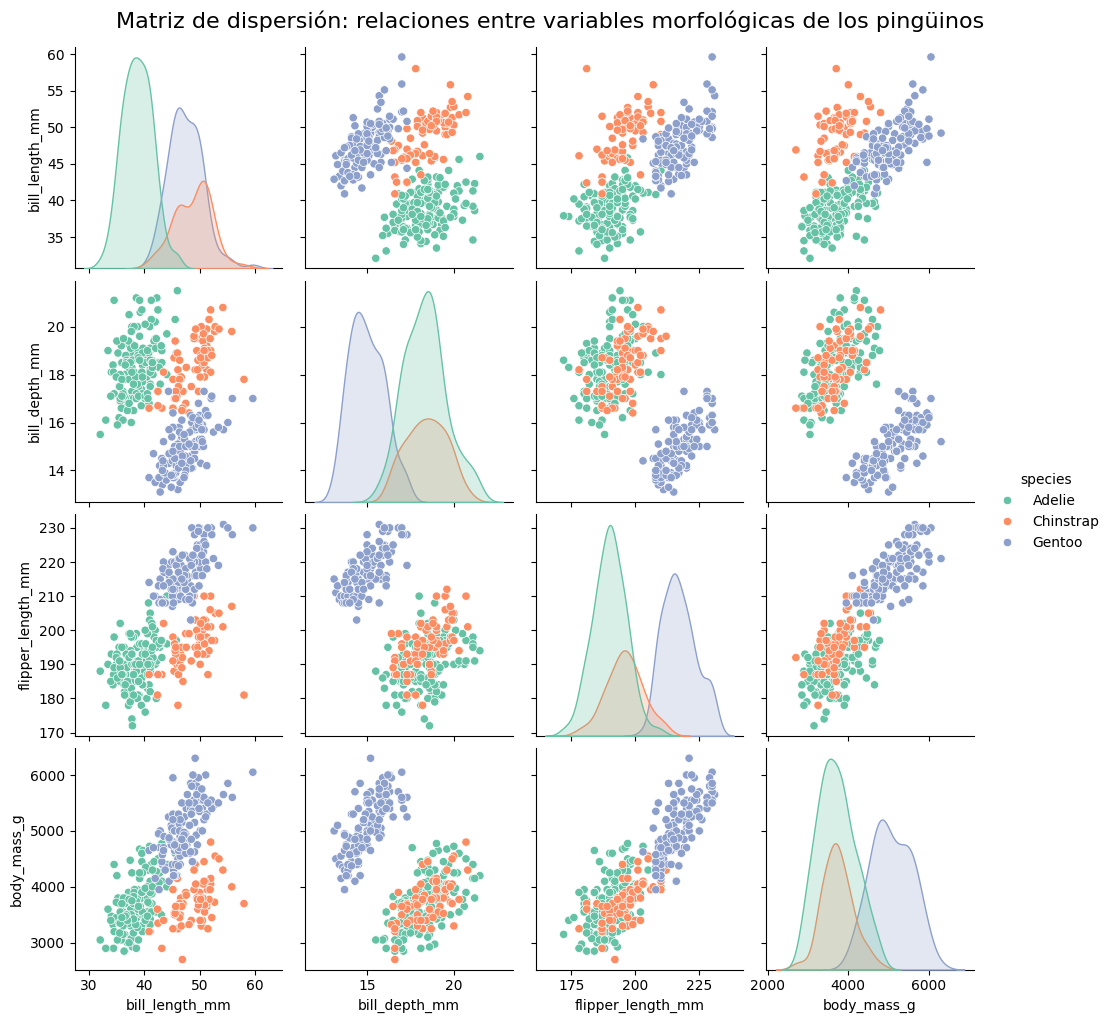


Matriz de autovectores (componentes principales):
                        PC1       PC2
bill_length_mm     0.455250  0.597031
bill_depth_mm     -0.400335  0.797767
flipper_length_mm  0.576013  0.002282
body_mass_g        0.548350  0.084363


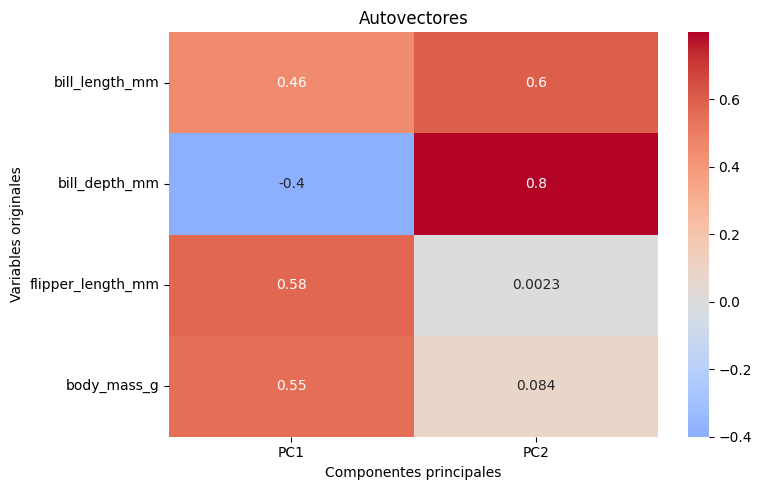

Ecuaciones de los componentes principales:

PC1 = 0.455·'bill_length_mm' + -0.4·'bill_depth_mm' + 0.576·'flipper_length_mm' + 0.548·'body_mass_g'
PC2 = 0.597·'bill_length_mm' + 0.798·'bill_depth_mm' + 0.002·'flipper_length_mm' + 0.084·'body_mass_g'

Porcentaje de varianza explicada por cada componente principal:
PC1: 68.84%
PC2: 19.31%

Varianza total explicada por las dos primeras componentes: 88.16%


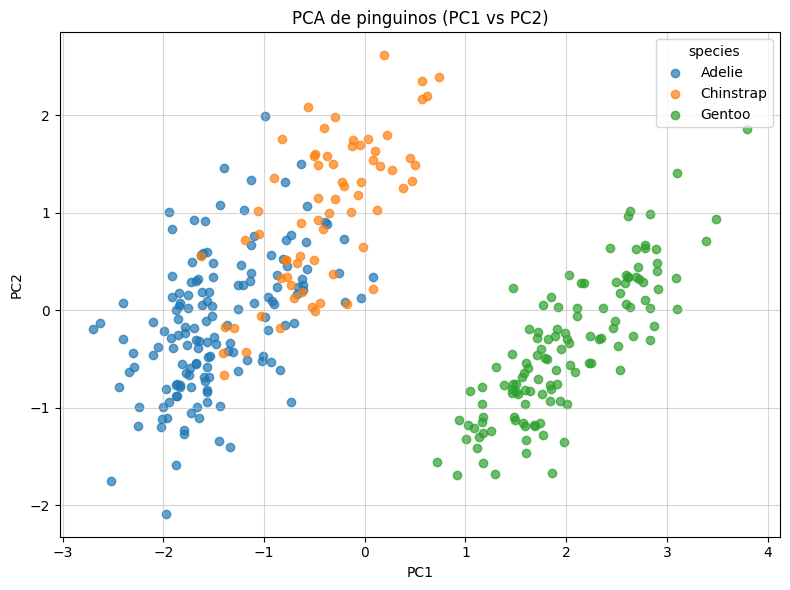

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

penguins = sns.load_dataset("penguins")

#seleccionar variables morfológicas
vars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_clean = penguins.dropna(subset=vars + ['species'])

# verificar si hay valores nulos y mostrar descripción estadística
print("Valores nulos en el dataset:\n", penguins_clean[vars].isnull().sum())
print("Descripcion estadistica de las variables seleccionadas:\n", penguins_clean[vars].describe())

sns.pairplot(penguins_clean, vars=vars, hue='species', palette='Set2', diag_kind='kde', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables morfológicas de los pingüinos', fontsize=16, y=1.02)
plt.show()

#estandarizar
penguins_estandarizado = StandardScaler().fit_transform(penguins_clean[vars])

# PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(penguins_estandarizado)

#matriz de autovectores (componentes principales)
componentes_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=vars
)
print("\nMatriz de autovectores (componentes principales):")
print(componentes_df)
plt.figure(figsize=(8, 5))
sns.heatmap(componentes_df, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

#ecuaciones de los componentes principales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(['PC1', 'PC2']):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{vars[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

#porcentaje de varianza explicada por cada CP
varianza_explicada = pca.explained_variance_ratio_
print("\nPorcentaje de varianza explicada por cada componente principal:")
for i, var in enumerate(varianza_explicada):
    print(f"PC{i+1}: {var*100:.2f}%")

print(f"\nVarianza total explicada por las dos primeras componentes: {varianza_explicada.sum()*100:.2f}%")

#graficar los resultados diferenciando por especie
plt.figure(figsize=(8,6))
for especie in penguins_clean['species'].unique():
    idx = penguins_clean['species'] == especie
    plt.scatter(componentes[idx, 0], componentes[idx, 1], label=especie, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de pinguinos (PC1 vs PC2)")
plt.legend(title="species")
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

## Interpretacion

El análisis de componentes principales (PCA) aplicado a las variables morfológicas de los pingüinos muestra que las dos primeras componentes principales explican el 88,16% de la varianza total de los datos (PC1: 68,84%, PC2: 19,31%). Esto significa que casi toda la información relevante de las cuatro variables originales se conserva en el plano PC1 vs PC2.

En el gráfico de dispersión (PC1 vs PC2), se observa que la especie Gentoo (en verde) se separa claramente de las demás, formando un grupo bien definido y aislado en el espacio reducido. Por otro lado, las especies Adelie (azul) y Chinstrap (naranja) aparecen más cercanas y con cierto solapamiento, lo que indica que sus características morfológicas son más similares y, por lo tanto, más difíciles de distinguir únicamente con este análisis.

Esta separación sugiere que el PCA es muy efectivo para diferenciar a Gentoo, pero menos discriminante entre Adelie y Chinstrap. La alta varianza explicada confirma que el plano PC1-PC2 resume muy bien la estructura de los datos originales.

### <span style="color:#2F749F;"><strong>Ejercicio 2: Regresión Lineal Múltiple</strong></span>  

A partir de un conjunto de datos real sobre diamantes, realiza un análisis de regresión lineal múltiple para predecir el precio en función de variables numéricas relacionadas con sus características físicas.  

1. Carga el conjunto de datos `diamonds` desde la librería seaborn `load_dataset("diamonds")`.  
2. Selecciona las siguientes variables predictoras para el análisis:  
   - `carat`  
   - `depth`  
   - `table`  
   - `x`  
   - `y`  
   - `z`  
3. Define como variable respuesta el precio (`price`).  
4. Divide los datos en entrenamiento y prueba para validar el modelo.  
5. Ajusta un modelo de **Regresión Lineal Múltiple** usando `statsmodels.OLS()`.  
6. Imprime el resumen del modelo (coeficientes, significancia, R² ajustado, etc.).  
7. Evalúa el desempeño del modelo con métricas de ajuste como **RMSE** y **R²** en el conjunto de prueba.  
8. Grafica los valores reales vs. los valores predichos del precio para interpretar la calidad del ajuste.  

<p align="center">
    <img src="imgs\sp_3_e2.png" alt="sp_3_e2" width="600"  height="400">
</p>



                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                 4.391e+04
Date:                Thu, 11 Sep 2025   Prob (F-statistic):               0.00
Time:                        09:00:20   Log-Likelihood:            -3.7672e+05
No. Observations:               43152   AIC:                         7.534e+05
Df Residuals:                   43145   BIC:                         7.535e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.098e+04    497.170     42.192      0.0

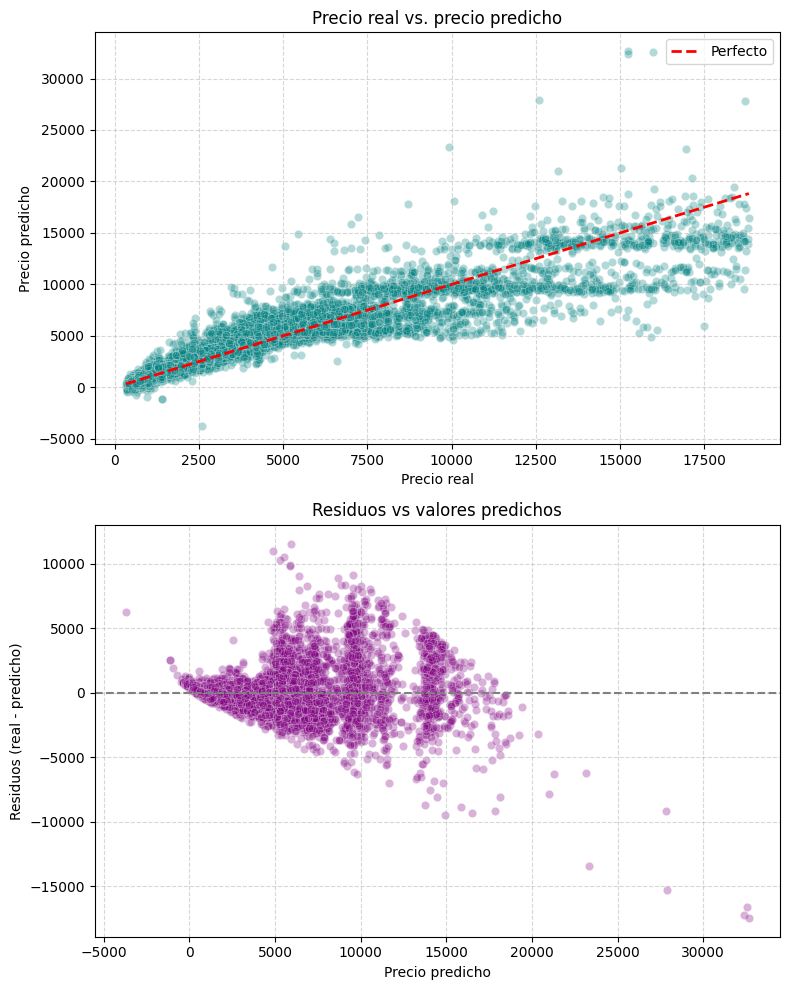

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

diamonds = sns.load_dataset("diamonds")

# variables predictoras y variable objetivo
vars_pred = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = diamonds[vars_pred]
y = diamonds['price']

# partir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# modelo de regresión lineal
X_train_const = sm.add_constant(X_train)
modelo = sm.OLS(y_train, X_train_const).fit()
print(modelo.summary())

# predección y evaluación en test
X_test_const = sm.add_constant(X_test)
y_pred = modelo.predict(X_test_const)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nRMSE en test: {rmse:.2f}")
print(f"R² en test: {r2:.4f}")

# Visualización tipo "cours" : valeurs réelles vs. prédites + résidus vs. ajustés
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Dispersión: valeurs réelles vs. valeurs prédites
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color='teal', alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfecto')
axes[0].set_title("Precio real vs. precio predicho")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residuos vs valores ajustados
sns.scatterplot(x=y_pred, y=y_test - y_pred, ax=axes[1], color='purple', alpha=0.3)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title("Residuos vs valores predichos")
axes[1].set_xlabel("Precio predicho")
axes[1].set_ylabel("Residuos (real - predicho)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretacion 

El estadístico Durbin-Watson obtenido en el modelo es cercano a 2, lo que indica que los residuos son independientes y no presentan autocorrelación, así que por ese lado el supuesto de independencia se cumple. Sin embargo, al analizar el gráfico de residuos frente a los valores predichos, se observa una especie de patrón en forma de onda, lo que sugiere que la relación entre las variables predictoras y el precio no es completamente lineal. Esto significa que, aunque el modelo de regresión lineal múltiple logra capturar parte de la variabilidad del precio, no consigue explicar toda la complejidad de los datos. Por lo tanto, sería recomendable considerar transformaciones de las variables o probar modelos no lineales para mejorar el ajuste


In [6]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Calcul des residuos et valeurs ajustées sur le test
residuos = y_test - y_pred
valores_ajustados = y_pred

# Prueba de Breusch-Pagan (sur le test)
X_test_const = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuos, X_test_const)
labels = ['LM Stat', 'p-value', 'F Stat', 'F p-value']
print("Breusch-Pagan test:")
for l, v in zip(labels, bp_test):
    print(f"{l}: {v:.4f}")


Breusch-Pagan test:
LM Stat: 2153.3721
p-value: 0.0000
F Stat: 448.1086
F p-value: 0.0000


## Interpretacion

El gráfico de residuos frente a los valores ajustados muestra un patrón en forma de abanico, lo que sugiere que la varianza de los errores no es constante. Además, la prueba de Breusch-Pagan arroja un p-valor muy bajo (p < 0.05), confirmando la presencia de heterocedasticidad en el modelo. Esto significa que el supuesto de homocedasticidad no se cumple en estos datos, por lo que las inferencias sobre los coeficientes pueden no ser totalmente fiables. 

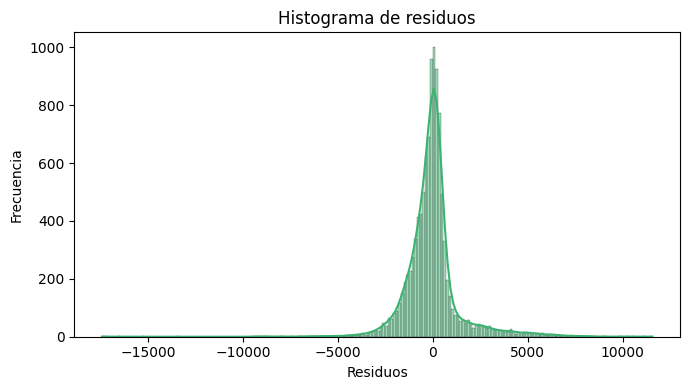

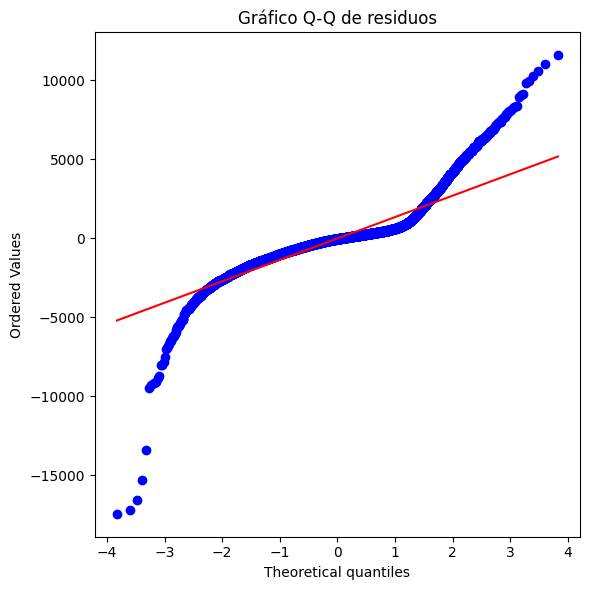

Shapiro-Wilk p-valor: 0.0000
Kolmogorov-Smirnov p-valor: 0.0000


/home/totox/Documents/UdeA/CiencasDatos_UdeA_GIRAULT/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10788.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
import scipy.stats as stats

# residuos
plt.figure(figsize=(7,4))
sns.histplot(residuos, kde=True, color='mediumseagreen')
plt.title("Histograma de residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure(figsize=(6,6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Gráfico Q-Q de residuos")
plt.tight_layout()
plt.show()

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk p-valor: {shapiro_p:.4f}")

# Prueba de Kolmogorov-Smirnov (comparando con normal estándar)
ks_stat, ks_p = stats.kstest((residuos - residuos.mean())/residuos.std(), 'norm')
print(f"Kolmogorov-Smirnov p-valor: {ks_p:.4f}")

## Interpretacion 

El histograma de los residuos no presenta una forma perfectamente simétrica de campana, lo que sugiere cierta desviación respecto a la normalidad. En el gráfico Q-Q, se observa que los puntos no siguen exactamente la línea diagonal, especialmente en los extremos, lo que indica la presencia de colas más largas o asimetría en la distribución de los errores. Además, tanto la prueba de Shapiro-Wilk como la de Kolmogorov-Smirnov arrojan p-valores muy bajos (p < 0.05), lo que permite rechazar la hipótesis de normalidad de los residuos. Sin embargo, dado el gran tamaño de la muestra, estas pruebas tienden a ser muy sensibles a pequeñas desviaciones. Por eso, es importante complementar la interpretación con la inspección visual de los gráficos.
